# Predicting Reversibility of Photomechanical Molecular Crytals

### Problem Statement

Molecular crystals respond to a light stimulus by diverse kinematic behaviors ranging form reversibly bending and twisting to irrevesibly fragmentating, jumping, and exploding. These behaviors are known to be affected by, among others, the intensity of the incident light, the aspect ratios of crystal geometries, and the volume changes accompanying phase transformation. While these factors, individually, explain the increase in internal energy of the system and its subsequent minimization through macroscopic deformation, they do not fully explain why some crystals revesibly bend and twist while others fragment and jump?

#### Goal

Studies in litrature have focused on individual factors but do not capture the complex interplay of various of these facotrs in governing the photomechanical response. In this project, we aim at predicting whether a crystal undergoes reversible or irrersible photomechanical deformation undergiven conditions such as light intesity, crystal geometry etc.

#### Motivation

The predictive framework could serve as a tool for designing molecular crystalline systems with porgrammable photomechanical response.

## Import Libraries

In [256]:
#import libraries here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fractions import Fraction
from sklearn.model_selection import train_test_split

## Read the data set

In [257]:
data = pd.read_csv("MolecularCrystalData.csv")

### Understand the data

In [258]:
print(f"Shape of the dataset: {data.shape}")
data.head() # To visualize top rows on the data

Shape of the dataset: (22, 36)


,Sample Index,reversible,reversible binary,wavelength nm,intensity mW/cm^2,temperature K,L/W,L/T,Z ratio,Z' ratio,...,Stretch 13,Stretch 22,Stretch 23,Stretch 33,Det U,Abs(DetU-1),Abs(lamda2-1),lambda 1,lambda 2,lambda 3
0,1,Yes,1,367,100.0,298.0,1.490,4.62,2.0,2.0,...,-0.034123,1.030610,-0.041252,1.02429,1.00148,0.00148,0.010853,1.07929,0.989147,0.938085
1,2,No,0,367,400.0,298.0,1.490,4.62,2.0,2.0,...,-0.034123,1.030610,-0.041252,1.02429,1.00148,0.00148,0.010853,1.07929,0.989147,0.938085
2,3,yes,1,365,80.0,298.0,1.604,2.73,1.0,2.0,...,-0.028921,0.995543,-0.047572,1.01102,1.00517,0.00517,0.012002,1.06690,0.987998,0.953584
3,4,yes,1,365,60.0,298.0,4.330,113.00,1.0,2.0,...,-0.028921,0.995543,-0.047572,1.01102,1.00517,0.00517,0.012002,1.06690,0.987998,0.953584
4,5,yes,1,365,70.0,287.0,40.000,36.80,1.0,1.0,...,-0.001468,1.007180,-0.000169,1.00321,1.01396,0.01396,0.004760,1.00726,1.004760,1.001880


In [259]:
data.info() # See the information about colums, no of non-null entries and their data type
# data.describe() # Un comment if we are interested in mean, standard deviation, and other metrics about the feature values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 36 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sample Index       22 non-null     int64  
 1   reversible         22 non-null     object 
 2   reversible binary  22 non-null     int64  
 3   wavelength nm      22 non-null     int64  
 4   intensity mW/cm^2  15 non-null     float64
 5   temperature K      11 non-null     float64
 6   L/W                21 non-null     float64
 7   L/T                21 non-null     float64
 8   Z ratio            21 non-null     float64
 9   Z' ratio           21 non-null     float64
 10  Ratio of symmetry  22 non-null     object 
 11  density ratio      22 non-null     float64
 12  ref a              22 non-null     float64
 13  ref b              22 non-null     object 
 14  ref c              22 non-null     float64
 15  ref alpha          22 non-null     float64
 16  ref beta           22 non-nu

We notice that Ratio of symmetry and ref b are by mistake classfied as object, we need to fix this.

In [260]:
for col in data.columns:

    if data[col].dtype == "object":

        print("\nCOLUMN:", col)

        print(data[col].unique())


COLUMN: reversible
['Yes' 'No' 'yes' 'no']

COLUMN: Ratio of symmetry
['1' '1/2' '2' '0.5']

COLUMN: ref b
['11.755' '9.9126' '20.612' '8.4961' '12.224' '9.6333' '20.232' '14.1661'
 '25.2733`' '13.9757' '34.95' '14.0747' '6.2376' '25.7066' '25.752'
 '5.9699' '15.4421']


In [261]:
data["ref b"] = (
    data["ref b"]
    .str.replace("`", "", regex=False)
    .astype(float)
)

In [262]:
data["Ratio of symmetry"] = (
    data["Ratio of symmetry"]
    .apply(lambda x: float(Fraction(str(x))))
)

In [263]:
data.info() # See the information about colums, no of non-null entries and their data type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 36 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sample Index       22 non-null     int64  
 1   reversible         22 non-null     object 
 2   reversible binary  22 non-null     int64  
 3   wavelength nm      22 non-null     int64  
 4   intensity mW/cm^2  15 non-null     float64
 5   temperature K      11 non-null     float64
 6   L/W                21 non-null     float64
 7   L/T                21 non-null     float64
 8   Z ratio            21 non-null     float64
 9   Z' ratio           21 non-null     float64
 10  Ratio of symmetry  22 non-null     float64
 11  density ratio      22 non-null     float64
 12  ref a              22 non-null     float64
 13  ref b              22 non-null     float64
 14  ref c              22 non-null     float64
 15  ref alpha          22 non-null     float64
 16  ref beta           22 non-nu

In [264]:
for col in data.columns:

    if data[col].dtype == "object":

        print("\nCOLUMN:", col)

        print(data[col].unique())


COLUMN: reversible
['Yes' 'No' 'yes' 'no']


### Visualize missing values in the dataset

In [265]:
missing = data.isnull().sum()
missing_percent = 100 * missing / len(data)

missing_table = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_table[missing_table["Missing Count"] > 0]

,Missing Count,Missing %
intensity mW/cm^2,7,31.818182
temperature K,11,50.000000
L/W,1,4.545455
L/T,1,4.545455
Z ratio,1,4.545455
Z' ratio,1,4.545455


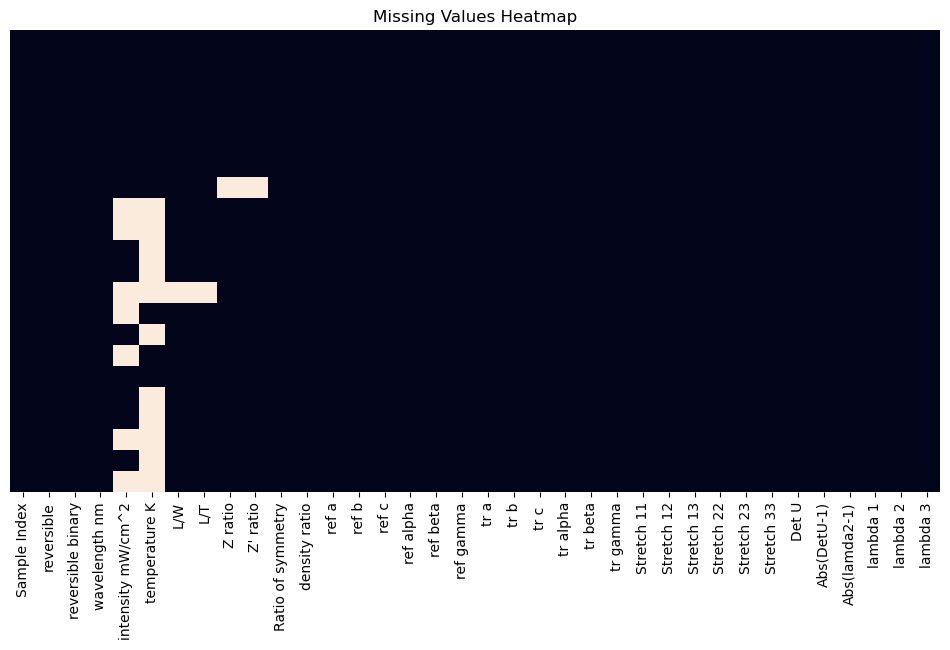

In [266]:
# Visualize heat map to see the missing data
plt.figure(figsize=(12,6))

sns.heatmap(
    data.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")
plt.show()

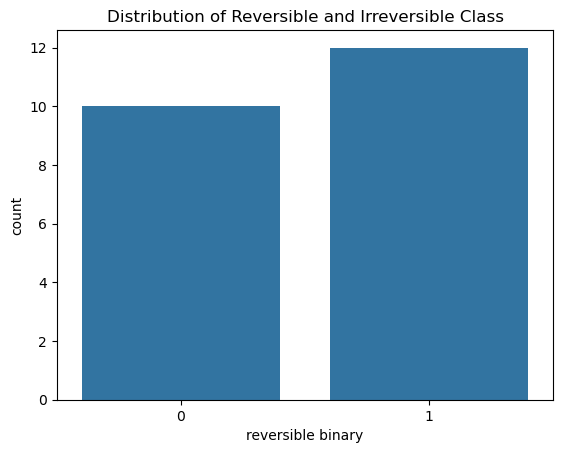

In [267]:
# Visualize distribution of two target classes
sns.countplot(data=data, x='reversible binary')

plt.title("Distribution of Reversible and Irreversible Class")
plt.show()

In [268]:
# Number of features with numerical data, for the remaining categorical data we can use one-hot-enconding
numeric_cols = data.select_dtypes(include=np.number).columns
print(f"No of features with numerical values: {len(numeric_cols)}")
print(numeric_cols)

No of features with numerical values: 35
Index(['Sample Index', 'reversible binary', 'wavelength nm',
       'intensity mW/cm^2', 'temperature K', 'L/W', 'L/T', 'Z ratio',
       'Z' ratio', 'Ratio of symmetry', 'density ratio', 'ref a', 'ref b',
       'ref c', 'ref alpha', 'ref beta', 'ref gamma', 'tr a', 'tr b', 'tr c ',
       'tr alpha', 'tr beta', 'tr gamma', 'Stretch 11', 'Stretch 12',
       'Stretch 13', 'Stretch 22', 'Stretch 23', 'Stretch 33', 'Det U',
       'Abs(DetU-1)', 'Abs(lamda2-1)', 'lambda 1', 'lambda 2', 'lambda 3'],
      dtype='object')


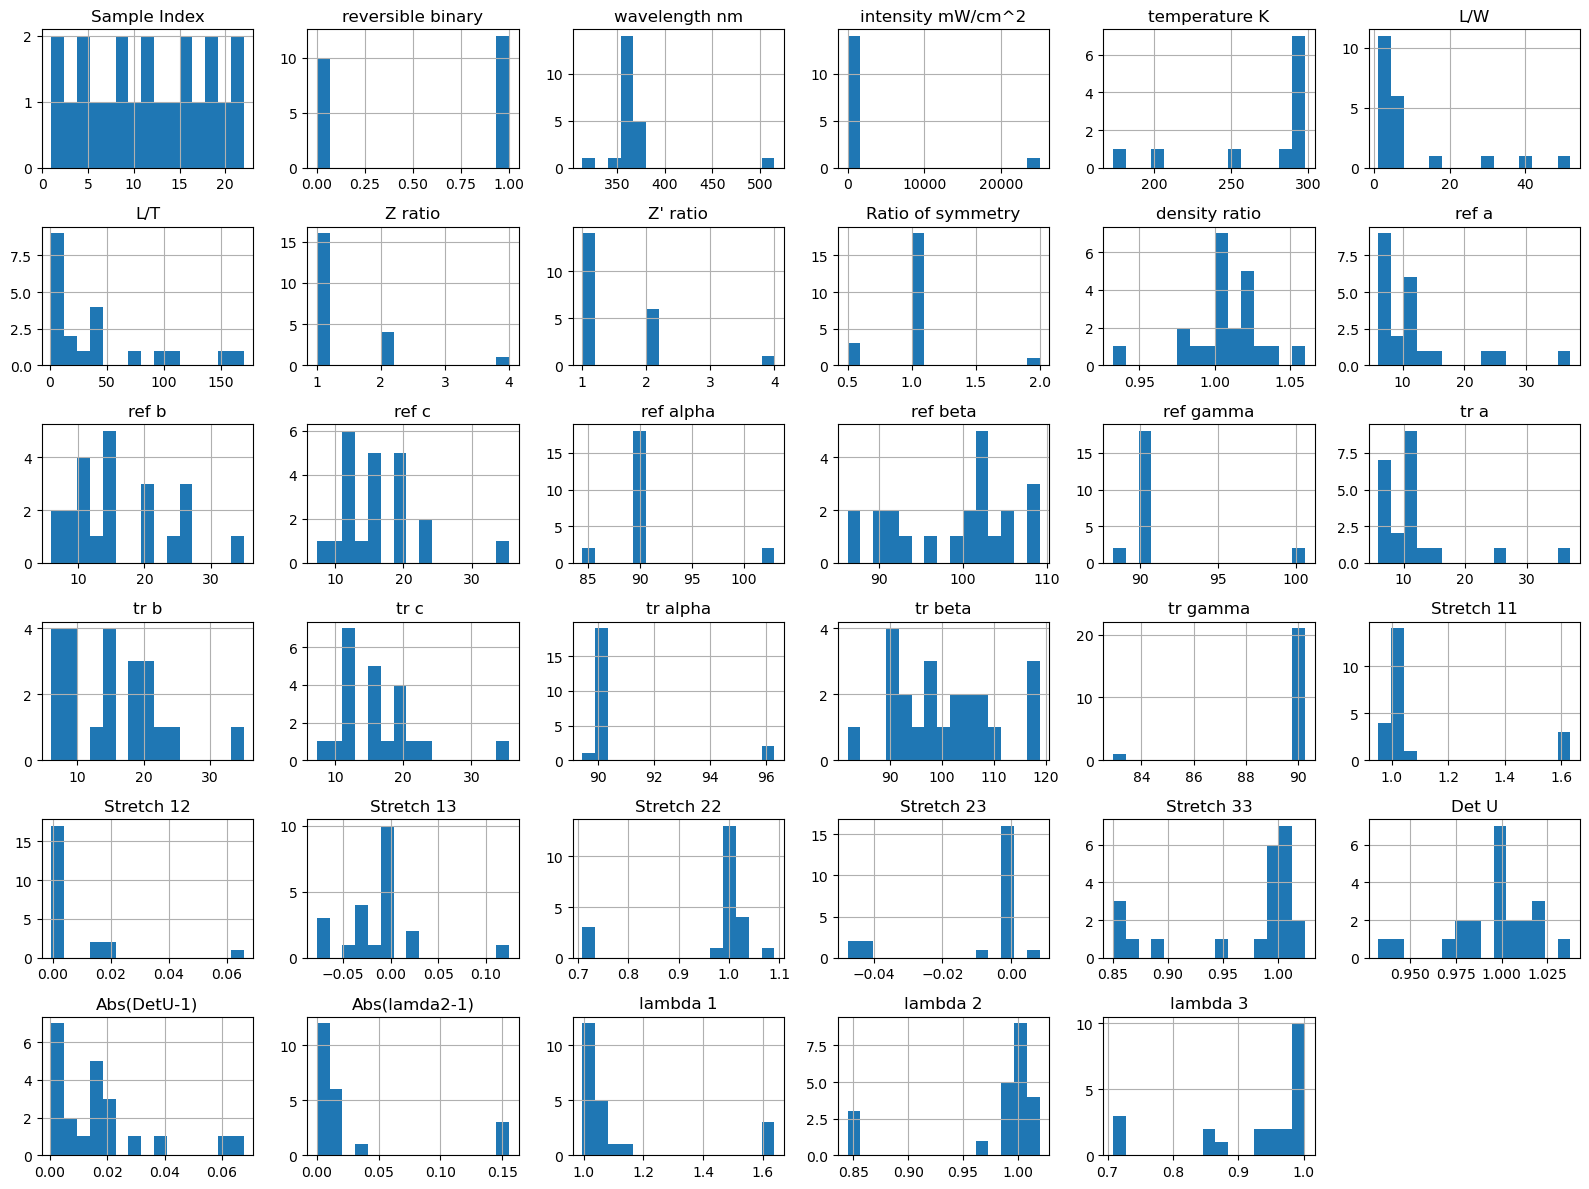

In [269]:
# understand the distribution of the range of feature data
data[numeric_cols].hist(
    figsize=(16,12),
    bins=15
)

plt.tight_layout()
plt.show()

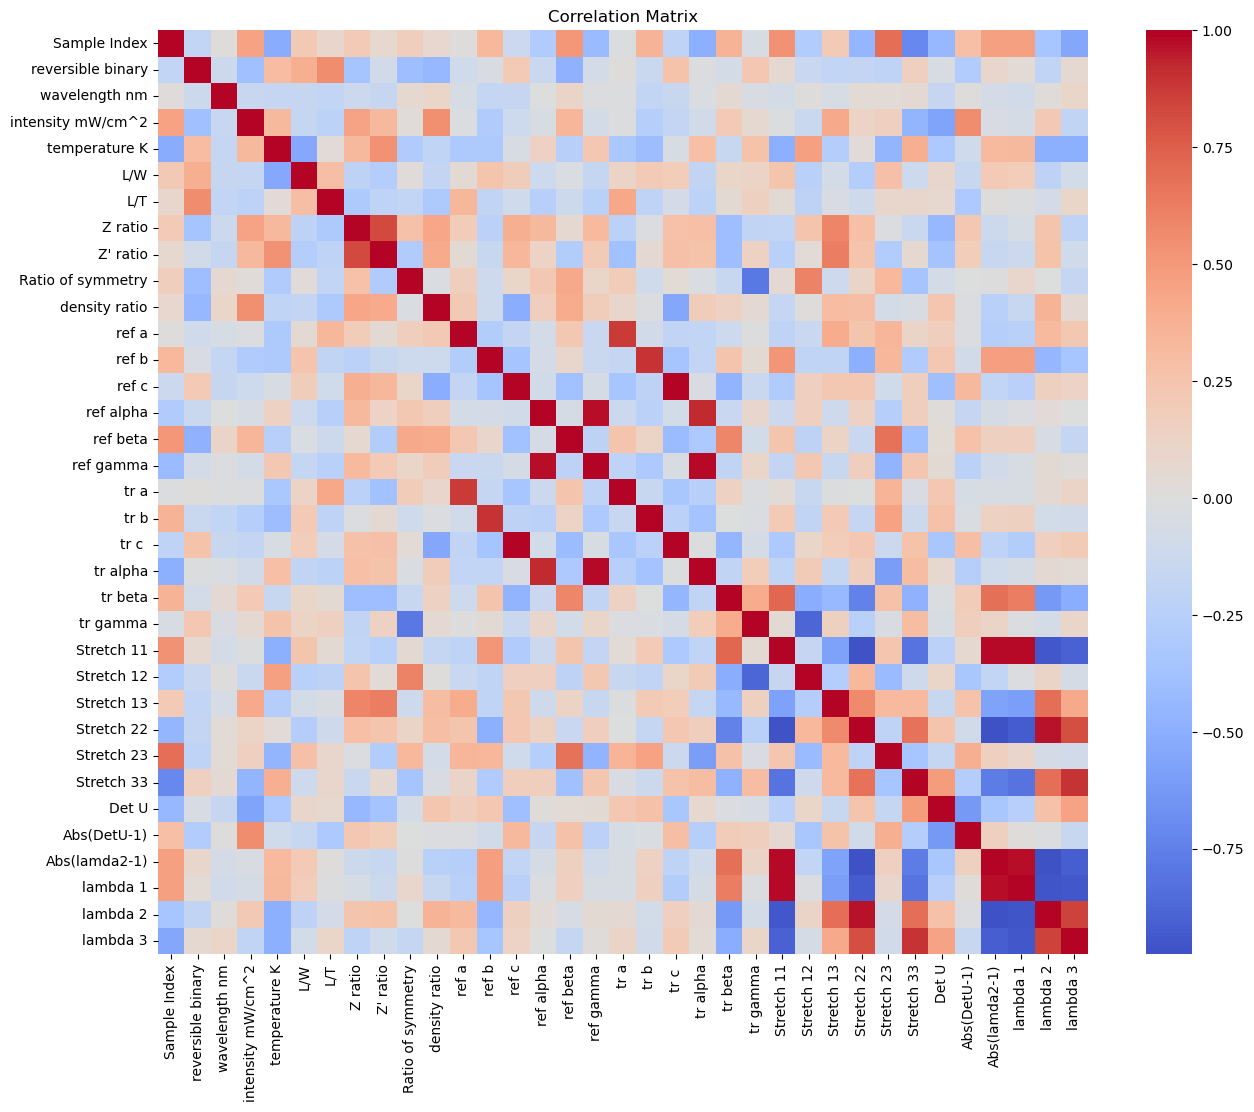

In [270]:
# Understand the correlation between the features
# Correlation with the target class can give an intutition before training any data
corr = data[numeric_cols].corr()

plt.figure(figsize=(15,12))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Matrix")
plt.show()

In [271]:
# Correlation with the target class
corr_target = corr["reversible binary"].sort_values(
    ascending=False
)

print(corr_target)

reversible binary    1.000000
L/T                  0.557452
L/W                  0.384730
temperature K        0.310473
tr c                 0.261531
tr gamma             0.234921
ref c                0.211175
Stretch 33           0.162951
Abs(lamda2-1)        0.086348
lambda 3             0.060831
Stretch 11           0.059188
lambda 1             0.040670
tr a                 0.007894
tr alpha            -0.012249
ref b               -0.037734
Det U               -0.047429
ref gamma           -0.074290
tr beta             -0.078585
Z' ratio            -0.093495
ref a               -0.101078
wavelength nm       -0.124889
ref alpha           -0.135156
tr b                -0.136191
Stretch 12          -0.149222
Stretch 22          -0.174204
Stretch 13          -0.182850
Sample Index        -0.187055
lambda 2            -0.191934
Stretch 23          -0.209809
Abs(DetU-1)         -0.287794
Z ratio             -0.356753
intensity mW/cm^2   -0.386642
Ratio of symmetry   -0.398527
density ra

## Cleaning the data

### 1. Impute the missing values if we think it is appropriate
### 2. Drom columns (features) with missing data
### 3. Drop rows (data points) with missing data

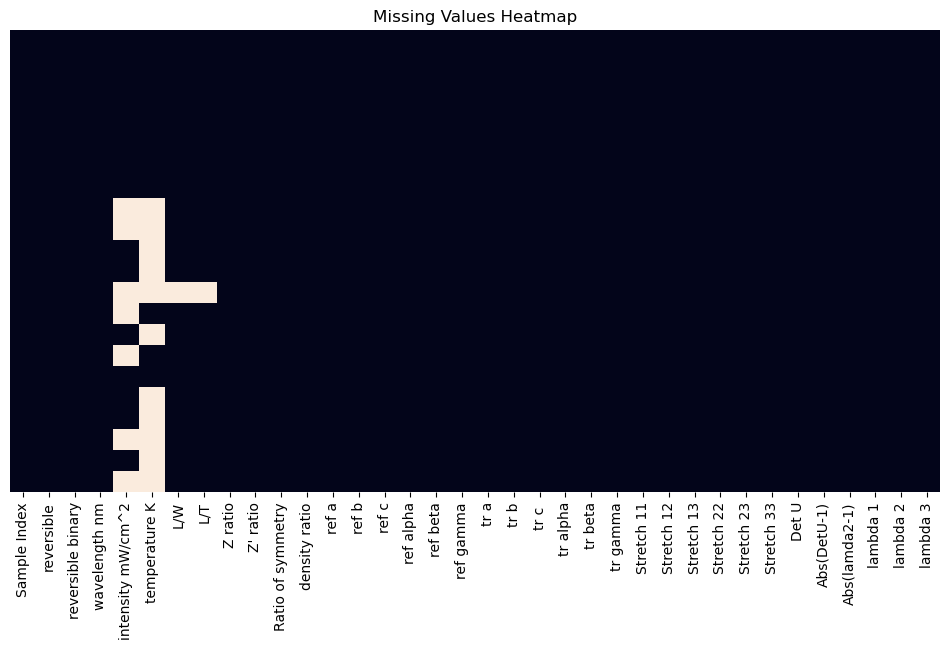

In [272]:
### Impute the missing Z and Z' values
data_filled = data.copy()

data_filled = data_filled.fillna({
    "Z ratio": 1,
    "Z' ratio": 1,
    #"temperature K": data["temperature K"].median(),
    #"intensity mW/cm^2": data["intensity mW/cm^2"].median()
})

# Visualize heat map to see the missing data
plt.figure(figsize=(12,6))

sns.heatmap(
    data_filled.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")
plt.show()

# save updated data file

data_filled.to_csv(
    "MolecularCrystalData_filledZ.csv",
    index=False
)

### Drop columns with missing data

In [273]:
cols_with_missing = data_filled.columns[data_filled.isnull().any()] #notice I have imputed data we can use raw data as well

print(cols_with_missing)

Index(['intensity mW/cm^2', 'temperature K', 'L/W', 'L/T'], dtype='object')


In [274]:
data_drop_cols = data_filled.dropna(axis=1)

print(data_drop_cols.shape)

# data_drop_cols.isnull().sum() # To verify the count of missing data from the features

(22, 32)


### Drop rows with missing values

In [275]:
data_drop_rows = data_filled.dropna()

print(data_drop_rows.shape)
# data_drop_rows.isnull().sum() # To verify the count of missing data from the features

(9, 36)


In [276]:
print("Original:", data.shape)

print("Drop Columns:", data_drop_cols.shape)

print("Drop Rows:", data_drop_rows.shape)

Original: (22, 36)
Drop Columns: (22, 32)
Drop Rows: (9, 36)


In [277]:
data_drop_cols.to_csv(
    "MolecularCrystalData_drop_columns.csv",
    index=False
)

data_drop_rows.to_csv(
    "MolecularCrystalData_drop_rows.csv",
    index=False
)

## Train-Test split and define target and features on the cleaned data

In [278]:
# Choose ONE of the cleaned dataset


# data = pd.read_csv("MolecularCrystalData_drop_columns.csv")

# data = pd.read_csv("MolecularCrystalData_drop_rows.csv")

data = pd.read_csv("MolecularCrystalData_filledZ.csv")

In [279]:
target = "reversible binary"

y = data[target]

X = data.drop(
    columns=[
        "reversible",
        "reversible binary"
    ]
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (22, 34)
y shape: (22,)


### Train-Test split

In [280]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (17, 34)
Testing : (5, 34)
